In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# Module 3 — Regression: from Calibration Curves to Regularization

**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *NIST StRD "Pontius" (Load Cell Calibration)* — Pontius, P., NIST. *Load Cell Calibration*. NIST Statistical Reference Datasets, https://www.itl.nist.gov/div898/strd/lls/data/Pontius.shtml (U.S. Government work — public domain) — ข้อมูลสอบเทียบ load cell จริง 40 จุด พร้อมค่าพารามิเตอร์ certified จาก NIST
- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). UCI ML Repository. https://doi.org/10.24432/C5002N (CC BY 4.0)

ไฟล์: `datasets/Pontius.dat`, `datasets/ccpp_power_plant.csv`

โมดูลนี้คือหัวใจของ "ML สำหรับเมโทรโลยี": **การสอบเทียบเครื่องมือคือ regression ที่เก่าแก่ที่สุดของงานวัด** เราจะเริ่มจากข้อมูลสอบเทียบจริงของ NIST ไปจนถึง regularization และ cross-validation

## 1. อ่านข้อมูลสอบเทียบจริงของ NIST

ไฟล์ `.dat` มีสองส่วน: ส่วนบนเป็นค่า certified (พารามิเตอร์และสถิติที่ NIST คำนวณเอง) ส่วนล่าง (บรรทัด 61–100) เป็นข้อมูลดิบ 40 จุด — คอลัมน์แรกคือ `y` (การอ่านค่าเครื่อง) และ `x` (แรงที่กด, หน่วยปอนด์)

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pont = pl.DataFrame(
    np.loadtxt(DATA / "Pontius.dat", skiprows=60, max_rows=40),
    schema={"y": pl.Float64, "x": pl.Float64},
    orient="row",
)
print(pont.shape)
pont.describe()

(40, 2)


statistic,y,x
str,f64,f64
"""count""",40.0,40.0
"""null_count""",0.0,0.0
"""mean""",1.143461,1.575e6
"""std""",0.632537,875961.010723
"""min""",0.11019,150000.0
"""25%""",0.65694,900000.0
"""50%""",1.20001,1.65e6
"""75%""",1.63194,2.25e6
"""max""",2.16844,3e6


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/c

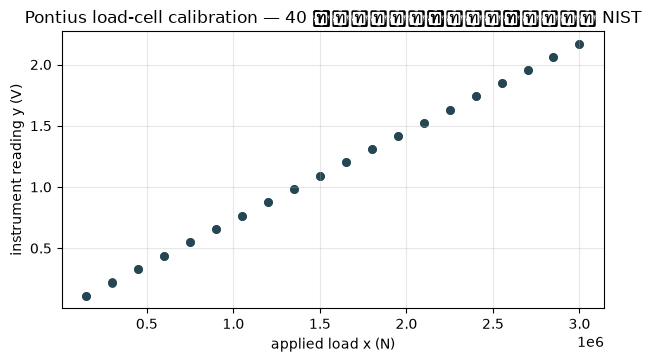

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(pont["x"], pont["y"], s=28, color="#264653")
ax.set_xlabel("applied load x (N)")
ax.set_ylabel("instrument reading y (V)")
ax.set_title("Pontius load-cell calibration — 40 จุดสอบเทียบจริงของ NIST")
ax.grid(alpha=0.3)
plt.show()

## 2. พอดีเส้นตรง — linear regression คือการ "สอบเทียบ" ฉบับพื้นฐาน

โมเดล: `y = b0 + b1·x` — เลือก b0, b1 ที่ทำให้ **ผลรวมกำลังสองของ residual น้อยที่สุด** (least squares) ในงานสอบเทียบ เส้นนี้คือ "สมการสอบเทียบ" ที่บอกว่าค่าอ่านควรแปลงเป็นค่าจริงอย่างไร

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Xp = pont.select("x")
yp = pont["y"]
lin = LinearRegression().fit(Xp, yp)
pred = lin.predict(Xp)

print(f"b0 = {lin.intercept_:.6g}, b1 = {lin.coef_[0]:.6g}")
print(f"R² = {r2_score(yp, pred):.6f} | RMSE = {np.sqrt(mean_squared_error(yp, pred)):.6g}")

b0 = 0.00614968, b1 = 7.22103e-07
R² = 0.999989 | RMSE = 0.00211629


## 3. Residual plot — กระจกส่องสิ่งที่เส้นพอดีไม่ได้

R² สูงลิ่ว (~0.9999) ดูเพอร์เฟกต์ แต่อย่าหยุดที่ตัวเลขเดียว — **พล็อต residual (ค่าจริง − ค่าพอดี) ต่อ x** เสมอ ถ้า residual มีรูปทรง แปลว่าโมเดลยังขาดอะไรอยู่

/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29394/2194295008.py:14: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sa

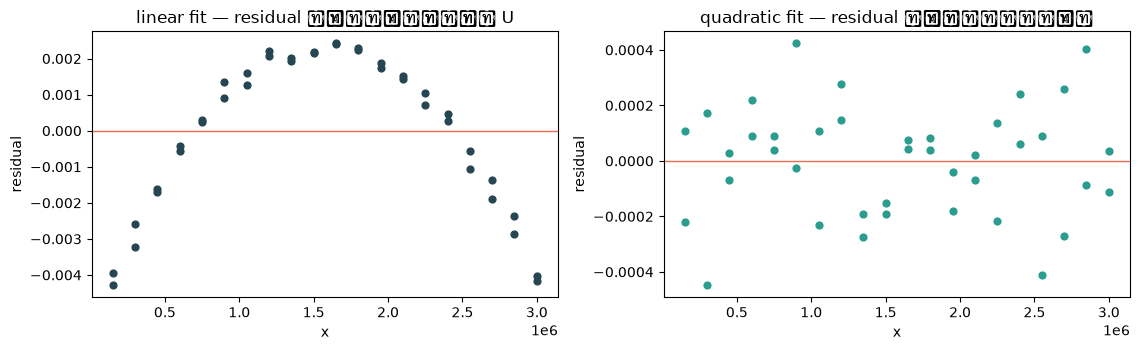

In [5]:
resid = np.asarray(yp) - pred

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].scatter(pont["x"], resid, s=24, color="#264653")
axes[0].axhline(0, color="#e76f51", lw=1)
axes[0].set_xlabel("x"); axes[0].set_ylabel("residual")
axes[0].set_title("linear fit — residual โค้งเป็นรูปตัว U")
quad = np.polyfit(pont["x"].to_numpy(), np.asarray(yp), 2)
resid_q = np.asarray(yp) - np.polyval(quad, pont["x"].to_numpy())
axes[1].scatter(pont["x"], resid_q, s=24, color="#2a9d8f")
axes[1].axhline(0, color="#e76f51", lw=1)
axes[1].set_xlabel("x"); axes[1].set_ylabel("residual")
axes[1].set_title("quadratic fit — residual ไม่มีโครงแล้ว")
fig.tight_layout()
plt.show()

residual ของเส้นตรงโค้งเป็นรูปตัว U ชัดเจน → ความสัมพันธ์จริงมีเทอม quadratic ที่โมเดลเชิงเส้นจับไม่ได้ และ NIST เองก็ออกใบรับรองโมเดล `y = B0 + B1·x + B2·x²` — ต่อไปเราจะพอดีตามรูปนั้นและ **เทียบกับค่า certified ของ NIST** ซึ่งเป็นแบบฝึกหัด "เช็กงานกับแหล่งอ้างอิง" แท้ ๆ

แต่ก่อนอื่นให้สังเกตปัญหาเชิงตัวเลขที่งานเมโทรโลยีเจอบ่อย: `x` มีขนาด ~10⁶ ทำให้ `x²` ~10¹² — เมทริกซ์ design มีเงื่อนไขเลวจน least squares แบบตรง ๆ ไม่เสถียร

In [6]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
Xq = poly.fit_transform(Xp)          # คอลัมน์: x, x²
bad_fit = LinearRegression().fit(Xq, yp)
print("fit แบบดิบ (ไม่ scale — ไม่เสถียร):",
      f"B0 = {bad_fit.intercept_:.4g}, B1 = {bad_fit.coef_[0]:.4g}, B2 = {bad_fit.coef_[1]:.4g}")

# วิธีที่เสถียร: np.polyfit จัด scaling ของคอลัมน์ให้ภายใน (และ NIST เองก็แก้แบบ centered)
b2, b1, b0 = np.polyfit(pont["x"].to_numpy(), np.asarray(yp), 2)
print(f"โมเดลของเรา:  B0 = {b0:.6g}, B1 = {b1:.6g}, B2 = {b2:.6g}")
print("NIST certified: B0 = 0.000673566, B1 = 0.000000732059, B2 = -3.1608e-15")

rmse_q = np.sqrt(mean_squared_error(yp, np.polyval([b2, b1, b0], pont["x"].to_numpy())))
print(f"RMSE quadratic = {rmse_q:.4g}")

fit แบบดิบ (ไม่ scale — ไม่เสถียร): B0 = 0.4457, B1 = 6.473e-20, B2 = 2.161e-13
โมเดลของเรา:  B0 = 0.000673566, B1 = 7.32059e-07, B2 = -3.16082e-15
NIST certified: B0 = 0.000673566, B1 = 0.000000732059, B2 = -3.1608e-15
RMSE quadratic = 0.0001973


ค่าที่เราคำนวณตรงกับ NIST ถึงหลักตัวเลขของ rounding — สองข้อคิดสำคัญ:

1. **scikit-learn/NumPy ให้ผลเดียวกับมาตรฐานสากล** เมื่อใช้ถูกวิธี — การ validate เครื่องมือซอฟต์แวร์ด้วยค่า certified ทำได้จริง เหมือนการ validate เครื่องมือวัด
2. **ตัวเลขใหญ่ต้อง scale ก่อน** — fit แบบดิบให้ค่าห่างไกลจาก certified ทั้งที่สูตรเดียวกัน; เหตุผลเดียวกับที่โมดูลก่อนหน้าย้ำเรื่อง scaling และเป็นวิธีเดียวกับที่ NIST แก้แบบ centered

## 4. กฎเหล็กของการสอบเทียบ: เส้นพอดีใช้ได้เฉพาะในช่วงที่สอบเทียบ

เราจะจงใจทำผิดเพื่อให้เห็น: พอดีโมเดลจาก **ครึ่งช่วงแรงล่าง** แล้วใช้ทำนายแรงสูงเกินช่วงที่เรียนรู้ (extrapolation)

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pyla

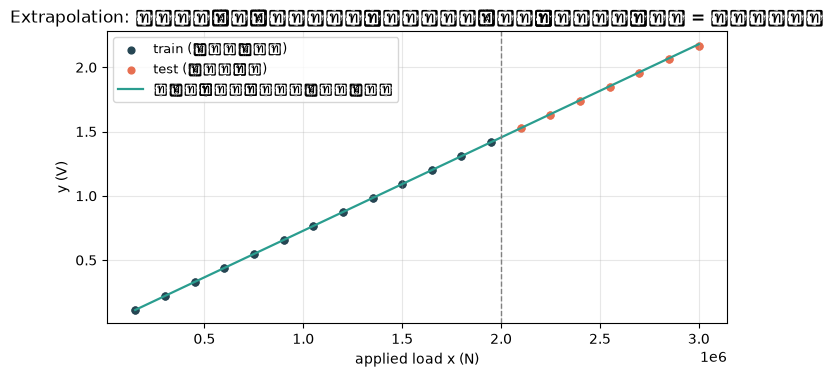

In [7]:
split_x = 2_000_000
mask_train = pont["x"] <= split_x
mask_test = pont["x"] > split_x

lin_low = LinearRegression().fit(pont.filter(mask_train).select("x"), pont.filter(mask_train)["y"])
grid = np.linspace(pont["x"].min(), pont["x"].max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.scatter(pont.filter(mask_train)["x"], pont.filter(mask_train)["y"], s=24, color="#264653", label="train (ช่วงล่าง)")
ax.scatter(pont.filter(mask_test)["x"], pont.filter(mask_test)["y"], s=24, color="#e76f51", label="test (ช่วงสูง)")
ax.plot(grid, lin_low.predict(grid), color="#2a9d8f", lw=1.6, label="เส้นที่พอดีจากช่วงล่าง")
ax.axvline(split_x, color="gray", ls="--", lw=1)
ax.set_xlabel("applied load x (N)"); ax.set_ylabel("y (V)")
ax.set_title("Extrapolation: การใช้เส้นสอบเทียบนอกช่วงที่สอบเทียบ = การเดา")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

In [8]:
pred_high = lin_low.predict(pont.filter(mask_test).select("x"))
actual_high = pont.filter(mask_test)["y"].to_numpy()
print("ค่าคลาดเคลื่อนเฉลี่ยในช่วง extrapolate:", f"{np.mean(np.abs(pred_high - actual_high)):.4g} V")
in_range_err = np.mean(np.abs(lin_low.predict(pont.filter(mask_train).select("x")) - pont.filter(mask_train)["y"].to_numpy()))
print("ค่าคลาดเคลื่อนเฉลี่ยในช่วงที่พอดี      :", f"{in_range_err:.4g} V")

ค่าคลาดเคลื่อนเฉลี่ยในช่วง extrapolate: 0.006361 V
ค่าคลาดเคลื่อนเฉลี่ยในช่วงที่พอดี      : 0.0007944 V


**สิ่งที่เห็น:** นอกช่วงที่สอบเทียบ ค่าคลาดเคลื่อนโตขึ้นหลายเท่า — สมการสอบเทียบทุกใบจึงเขียน "ช่วงใช้งาน" (calibration range) กำกับเสมอ และโมเดล ML ก็ไม่ต่าง: โมเดลที่เทรนจากข้อมูลช่วงหนึ่ง **ไม่มีสิทธิ์อวดความแม่นนอกช่วงนั้น**

## 5. Multivariate regression: CCPP และการทำนายหลายตัวแปร

In [9]:
ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
X = ccpp.select("AT", "V", "AP", "RH")
y = ccpp["PE"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlr = LinearRegression().fit(X_train, y_train)
print("สัมประสิทธิ์ต่อคอลัมน์:")
for name, c in zip(X.columns, mlr.coef_):
    print(f"  {name}: {c:.4f}")
print(f"test R² = {mlr.score(X_test, y_test):.4f}")

สัมประสิทธิ์ต่อคอลัมน์:
  AT: -1.9859
  V: -0.2321
  AP: 0.0622
  RH: -0.1581
test R² = 0.9301


## 6. Regularization — Ridge และ Lasso

ปัญหาของ OLS เมื่อ feature สัมพันธ์กัน (correlated features — สามัญมากในเครื่องวัดหลายช่อง): สัมประสิทธิ์จะแกว่งแรงและตีความยาก ทางแก้: เพิ่ม **บทลงโทษขนาดสัมประสิทธิ์** เข้าไปใน loss

- **Ridge** (บทลงโทษ L2): หดสัมประสิทธิ์ทุกตัวเข้าหาศูนย์ — เก็บทุก feature ไว้
- **Lasso** (บทลงโทษ L1): กดบางตัวจนเป็นศูนย์จริง — เลือก feature ให้ด้วย

ตัวควบคุมคือ `alpha` — ยิ่งใหญ่ยิ่งหดแรง

In [10]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1).fit(X_train, y_train)

comp = pl.DataFrame({
    "feature": X.columns,
    "OLS": mlr.coef_,
    "ridge(a=1)": ridge.coef_,
    "lasso(a=0.1)": lasso.coef_,
})
comp

feature,OLS,ridge(a=1),lasso(a=0.1)
str,f64,f64,f64
"""AT""",-1.9859,-1.985873,-1.980864
"""V""",-0.232094,-0.232104,-0.233737
"""AP""",0.0622,0.062207,0.060738
"""RH""",-0.158118,-0.158113,-0.156642


## 7. เลือก alpha ด้วย cross-validation — ไม่ใช้ test set ในการปรับ

หลักการ: แบ่ง train เป็น 5 ส่วน สลับกันใช้ 4 ส่วนเทรน 1 ส่วนตรวจ ทำ 5 รอบ แล้วเฉลี่ย — ตัวเลขที่ได้ใช้ปรับ hyperparameter ได้อย่างซื่อสัตย์ **โดยไม่แตะ test set**

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/IPython/co

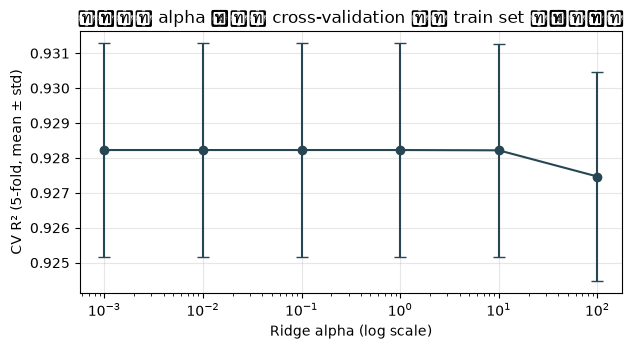

alpha ดีสุดจาก CV = 1.0


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cv_means, cv_stds = [], []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.errorbar(alphas, cv_means, yerr=cv_stds, marker="o", color="#264653", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Ridge alpha (log scale)")
ax.set_ylabel("CV R² (5-fold, mean ± std)")
ax.set_title("เลือก alpha ด้วย cross-validation บน train set เท่านั้น")
ax.grid(alpha=0.3)
plt.show()

best = alphas[int(np.argmax(cv_means))]
print(f"alpha ดีสุดจาก CV = {best}")

In [12]:
final = make_pipeline(StandardScaler(), Ridge(alpha=best)).fit(X_train, y_train)
print(f"test R² ของโมเดลสุดท้าย = {final.score(X_test, y_test):.4f}")

test R² ของโมเดลสุดท้าย = 0.9301


## 8. สรุปโมดูล

- Regression = การสอบเทียบเชิงสถิติ; งานเมโทรโลยีทำมาก่อน ML อยู่แล้ว เราแค่ต่อยอดเครื่องมือ
- **R² ไม่พอ** — พล็อต residual เสมอ รูปทรง residual บอกโมเดลที่ขาด
- ตรวจโค้ดสถิติกับค่า certified (NIST StRD) ได้ — validate เครื่องมือซอฟต์แวร์เช่นเดียวกับเครื่องมือวัด
- เส้นสอบเทียบใช้ได้เฉพาะช่วงที่สอบเทียบ — extrapolation คือการเดา
- Ridge/Lasso ควบคุมสัมประสิทธิ์เมื่อ feature สัมพันธ์กัน; เลือก alpha ด้วย CV บน train แล้วค่อยเปิด test ครั้งเดียว